## Import

In [1]:
!pip install pyts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import datetime
import yfinance as yf

from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

try:
    from pyts.image import GramianAngularField
except ImportError:
    print("Installing pyts...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'pyts'])
    from pyts.image import GramianAngularField

In [3]:
SEED = 1234
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Step 1

### a) Data Gathering & Description

In [4]:
# Data Gathering
ticker = 'BTC-USD'
interval = '1d'
start_date = '2019-01-01'
end_date = '2024-06-15'

print(f"Dataset: {ticker}")
print(f"Period: {start_date} to {end_date}")
print(f'Length: {(pd.to_datetime(end_date) - pd.to_datetime(start_date)).days} days')

Dataset: BTC-USD
Period: 2019-01-01 to 2024-06-15
Length: 1992 days


In [5]:
raw = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval=interval,
    auto_adjust=True,
    progress=False,
    threads=True
)

In [6]:
df = raw.copy()
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]
df['ret'] = df['Close'].pct_change()
df.dropna(inplace=True)

In [7]:
# Limit to 2000 observations as per assignment
if len(df) > 2000:
    df = df.tail(2000)
    print(f"Limited dataset to {len(df)} observations")

In [8]:
df.shape

(1991, 6)

In [9]:
df.describe()

Price,Open,High,Low,Volume,Close,ret
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
count,1991.000000,1991.000000,1991.000000,1.991000e+03,1991.000000,1991.000000
mean,27465.773547,28083.199087,26812.200255,2.931964e+10,27495.020655,0.002034
std,18365.461744,18804.533279,17873.707954,1.793965e+10,18375.205571,0.034528
min,3401.376465,3427.945557,3391.023682,4.530215e+09,3399.471680,-0.371695
25%,10152.268066,10313.309082,9879.011230,1.738347e+10,10152.258789,-0.012766
50%,24437.417969,25134.117188,24200.363281,2.601798e+10,24565.601562,0.000796
75%,41242.433594,42219.164062,40021.228516,3.659072e+10,41254.941406,0.016512
max,73079.375000,73750.070312,71334.093750,3.509679e+11,73083.500000,0.187465


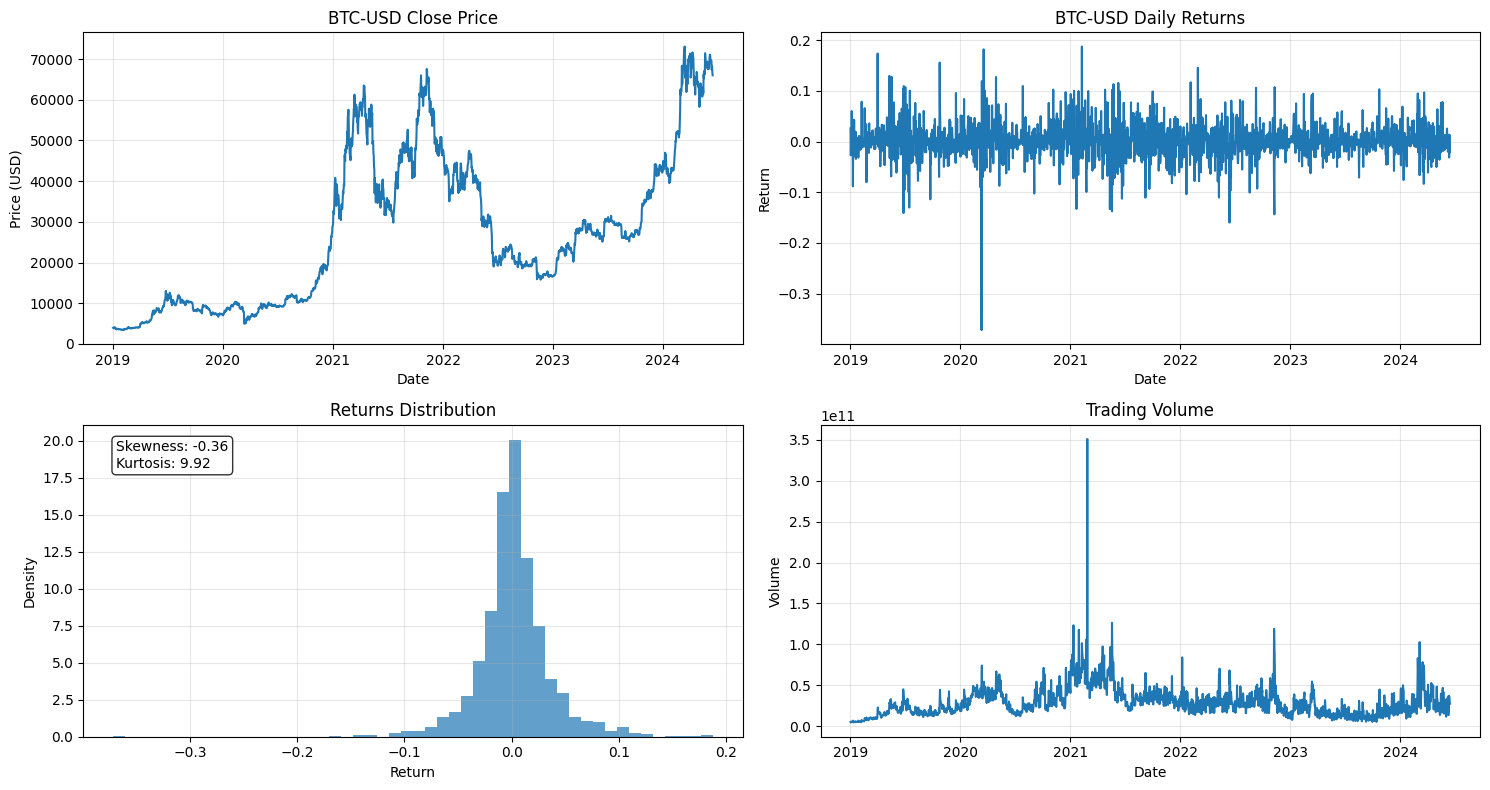

In [10]:
# Basic visualizations
plt.figure(figsize=(15, 8))

# Price plot
plt.subplot(2, 2, 1)
plt.plot(df.index, df['Close'])
plt.title("BTC-USD Close Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)

# Returns plot
plt.subplot(2, 2, 2)
plt.plot(df.index, df['ret'])
plt.title("BTC-USD Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)

# Returns histogram
plt.subplot(2, 2, 3)
plt.hist(df['ret'], bins=50, alpha=0.7, density=True)
plt.title("Returns Distribution")
plt.xlabel("Return")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)

# Add statistics
skew_val = skew(df['ret'].dropna())
kurt_val = kurtosis(df['ret'].dropna(), fisher=True)
plt.text(0.05, 0.95, f'Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Volume
plt.subplot(2, 2, 4)
plt.plot(df.index, df['Volume'])
plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- the return series is highly volatile
- returns fluctuate around zero without clear trend
- volatile clustering effect observed during the period
- leptokurtic distributed (fat tails)
- negative skewness, indicating more frequent negative returns than positive


In [11]:
# Stationarity tests
adf_price = adfuller(df['Close'])
adf_ret = adfuller(df['ret'])

print(f"\nStationarity Tests:")
print(f"Price ADF p-value: {adf_price[1]:.6f}")
print(f"Returns ADF p-value: {adf_ret[1]:.6f}")


Stationarity Tests:
Price ADF p-value: 0.749312
Returns ADF p-value: 0.000000


### b) Leakage Label Design

In [12]:
# Create features with intentional leakage
df_leak = df[['ret']].copy()
n_lag = 30

# Create lagged features (past data)
for k in range(1, n_lag):
    df_leak[f'ret_lag{k}'] = df_leak['ret'].shift(k)

# INTENTIONAL LEAKAGE: Target uses future returns
df_leak['future_30d_ret'] = df_leak['ret'].rolling(n_lag).apply(lambda x: np.prod(1 + x) - 1).shift(-n_lag)
df_leak['target'] = np.where(df_leak['future_30d_ret'] > 0, 1, 0)

# Clean up
df_leak = df_leak.dropna()

LEAKAGE EXPLANATION:
- Features: Returns from t-1 to t-29 (past 29 days)
- Target: Cumulative return from t+1 to t+30 (future 30 days)
- PROBLEM: Target uses information from the future that would not be
  available at prediction time, creating unrealistic performance
- Dataset shape after feature engineering: (1932, 32)

In [13]:
# Prepare data
X_leak = df_leak.drop(columns=['target', 'future_30d_ret'])
y_leak = df_leak['target']
dates = df_leak.index

print(f"Feature shape: {X_leak.shape}")
print(f"Target distribution: {y_leak.value_counts().to_dict()}")

Feature shape: (1932, 30)
Target distribution: {1: 1114, 0: 818}


In [14]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100):
    """Train model with proper validation"""
    # Class weights for imbalanced data
    pos_count = sum(y_train)
    neg_count = len(y_train) - pos_count

    if pos_count > 0 and neg_count > 0:
        weight_pos = len(y_train) / (2 * pos_count)
        weight_neg = len(y_train) / (2 * neg_count)
        class_weight = {0: weight_neg, 1: weight_pos}
    else:
        class_weight = None

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=20, restore_best_weights=True, verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        shuffle=False,
        class_weight=class_weight
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    return y_prob, y_pred

In [15]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Evaluate model performance"""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    }

    print(f"\n{model_name} Performance:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    return metrics

In [16]:
def backtest_strategy(predictions_df, original_df, model_name):
    # Reset index to ensure proper merging
    pred_df = predictions_df.copy()
    pred_df = pred_df.reset_index(drop=True)

    # Create a DataFrame with returns that matches prediction dates
    returns_df = original_df[['ret']].copy()
    returns_df = returns_df.reset_index()
    returns_df.columns = ['Date', 'Ret']

    # Merge on Date column (both should have Date columns now)
    if 'Date' not in pred_df.columns:
        pred_df['Date'] = pred_df.index

    # Ensure Date columns are datetime
    pred_df['Date'] = pd.to_datetime(pred_df['Date'])
    returns_df['Date'] = pd.to_datetime(returns_df['Date'])

    # Merge using inner join to avoid issues
    merged_df = pd.merge(pred_df, returns_df, on='Date', how='inner')

    if len(merged_df) == 0:
        print(f"Warning: No matching dates found for {model_name}")
        return None, 0, 0, 0

    # Calculate positions and returns
    merged_df["Positions"] = np.where(merged_df["y_pred"] == 1, 1, -1)
    merged_df["Positions_shift"] = merged_df["Positions"].shift(1)

    # Remove first row due to shift
    merged_df = merged_df.dropna()

    if len(merged_df) == 0:
        print(f"Warning: No data remaining after shift for {model_name}")
        return None, 0, 0, 0

    # Strategy returns
    merged_df["Strat_ret"] = merged_df["Positions_shift"] * merged_df["Ret"]
    merged_df["Strat_ret_L"] = np.where(merged_df["Positions_shift"] == 1,
                                       merged_df["Ret"], 0)

    # Cumulative returns
    merged_df["CumRet"] = (1 + merged_df["Strat_ret"]).cumprod() - 1
    merged_df["CumRet_L"] = (1 + merged_df["Strat_ret_L"]).cumprod() - 1
    merged_df["bhRet"] = (1 + merged_df["Ret"]).cumprod() - 1

    # Final returns
    if len(merged_df) > 0:
        final_ret_ls = merged_df["CumRet"].iloc[-1] * 100
        final_ret_l = merged_df["CumRet_L"].iloc[-1] * 100
        final_ret_bh = merged_df["bhRet"].iloc[-1] * 100
    else:
        final_ret_ls = final_ret_l = final_ret_bh = 0

    print(f"\n{model_name} Backtest Results:")
    print(f"  Long/Short Return: {final_ret_ls:.2f}%")
    print(f"  Long Only Return: {final_ret_l:.2f}%")
    print(f"  Buy & Hold Return: {final_ret_bh:.2f}%")

    # Count trades
    if len(merged_df) > 1:
        trades = int(merged_df["Positions"].diff().abs().sum() / 2)
        print(f"  Total Trades: {trades}")

    return merged_df, final_ret_ls, final_ret_l, final_ret_bh

Training Models with Single Train/Test Split (WITH LEAKAGE)

In [17]:
# Train/test split
split_idx = int(len(X_leak) * 0.7)
X_train = X_leak.iloc[:split_idx]
y_train = y_leak.iloc[:split_idx]
X_test = X_leak.iloc[split_idx:]
y_test = y_leak.iloc[split_idx:]
dates_test = dates[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1352, Test size: 580


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
results_step1 = {}

1. MLP Model

In [20]:
def build_mlp_classifier(input_dim, hp_lr=1e-4):
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(85, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(55, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(30, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [21]:
tf.keras.backend.clear_session()
model_mlp = build_mlp_classifier(X_train_scaled.shape[1])
y_prob_mlp, y_pred_mlp = train_model(model_mlp, X_train_scaled, y_train,
                                    X_test_scaled, y_test)

# Create predictions DataFrame with proper Date column
pred_df_mlp = pd.DataFrame({
    'Date': dates_test,
    'y_true': y_test.values,
    'y_prob': y_prob_mlp,
    'y_pred': y_pred_mlp
})

metrics_mlp = evaluate_model(y_test, y_pred_mlp, y_prob_mlp, "MLP")
backtest_mlp, ret_ls_mlp, ret_l_mlp, ret_bh_mlp = backtest_strategy(pred_df_mlp, df, "MLP")
results_step1['MLP'] = {'metrics': metrics_mlp, 'returns': [ret_ls_mlp, ret_l_mlp, ret_bh_mlp]}


MLP Performance:
  Accuracy: 0.3810
  Precision: 0.9167
  Recall: 0.0298
  F1: 0.0577
  ROC-AUC: 0.4949

MLP Backtest Results:
  Long/Short Return: -79.53%
  Long Only Return: 1.88%
  Buy & Hold Return: 245.40%
  Total Trades: 22


2. LSTM Model

In [22]:
def build_lstm_classifier(input_shape, hp_lr=1e-4):
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(50, return_sequences=True, dropout=0.2),
        tf.keras.layers.LSTM(25, dropout=0.2),
        tf.keras.layers.Dense(25, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [23]:
tf.keras.backend.clear_session()
# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model_lstm = build_lstm_classifier((X_train_lstm.shape[1], 1))
y_prob_lstm, y_pred_lstm = train_model(model_lstm, X_train_lstm, y_train,
                                      X_test_lstm, y_test)

pred_df_lstm = pd.DataFrame({
    'Date': dates_test,
    'y_true': y_test.values,
    'y_prob': y_prob_lstm,
    'y_pred': y_pred_lstm
})

metrics_lstm = evaluate_model(y_test, y_pred_lstm, y_prob_lstm, "LSTM")
backtest_lstm, ret_ls_lstm, ret_l_lstm, ret_bh_lstm = backtest_strategy(pred_df_lstm, df, "LSTM")
results_step1['LSTM'] = {'metrics': metrics_lstm, 'returns': [ret_ls_lstm, ret_l_lstm, ret_bh_lstm]}


LSTM Performance:
  Accuracy: 0.5483
  Precision: 0.6308
  Recall: 0.6992
  F1: 0.6632
  ROC-AUC: 0.4744

LSTM Backtest Results:
  Long/Short Return: 157.36%
  Long Only Return: 211.64%
  Buy & Hold Return: 245.40%
  Total Trades: 43


3. CNN GAF

In [24]:
def build_cnn_gaf_classifier(input_shape, hp_lr=1e-4):
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                 loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [25]:
def prepare_gaf_data(X_array):
    """Prepare GAF images from feature array"""
    transformer = GramianAngularField(image_size=X_array.shape[1], method="summation")
    X_gaf = transformer.transform(X_array)

    # Normalize each image individually
    X_scaled = np.empty_like(X_gaf)
    for i in range(X_gaf.shape[0]):
        img = X_gaf[i]
        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 0:
            img = (img - img_min) / (img_max - img_min)
        X_scaled[i] = img

    return (X_scaled * 255).astype("float32")[..., np.newaxis]

In [26]:
tf.keras.backend.clear_session()
X_train_gaf = prepare_gaf_data(X_train_scaled)
X_test_gaf = prepare_gaf_data(X_test_scaled)

model_cnn = build_cnn_gaf_classifier(X_train_gaf.shape[1:])
y_prob_cnn, y_pred_cnn = train_model(model_cnn, X_train_gaf, y_train,
                                    X_test_gaf, y_test)

pred_df_cnn = pd.DataFrame({
    'Date': dates_test,
    'y_true': y_test.values,
    'y_prob': y_prob_cnn,
    'y_pred': y_pred_cnn
})

metrics_cnn = evaluate_model(y_test, y_pred_cnn, y_prob_cnn, "CNN-GAF")
backtest_cnn, ret_ls_cnn, ret_l_cnn, ret_bh_cnn = backtest_strategy(pred_df_cnn, df, "CNN-GAF")
results_step1['CNN-GAF'] = {'metrics': metrics_cnn, 'returns': [ret_ls_cnn, ret_l_cnn, ret_bh_cnn]}


CNN-GAF Performance:
  Accuracy: 0.3603
  Precision: 0.4706
  Recall: 0.0434
  F1: 0.0794
  ROC-AUC: 0.4307

CNN-GAF Backtest Results:
  Long/Short Return: -75.16%
  Long Only Return: 11.30%
  Buy & Hold Return: 245.40%
  Total Trades: 60


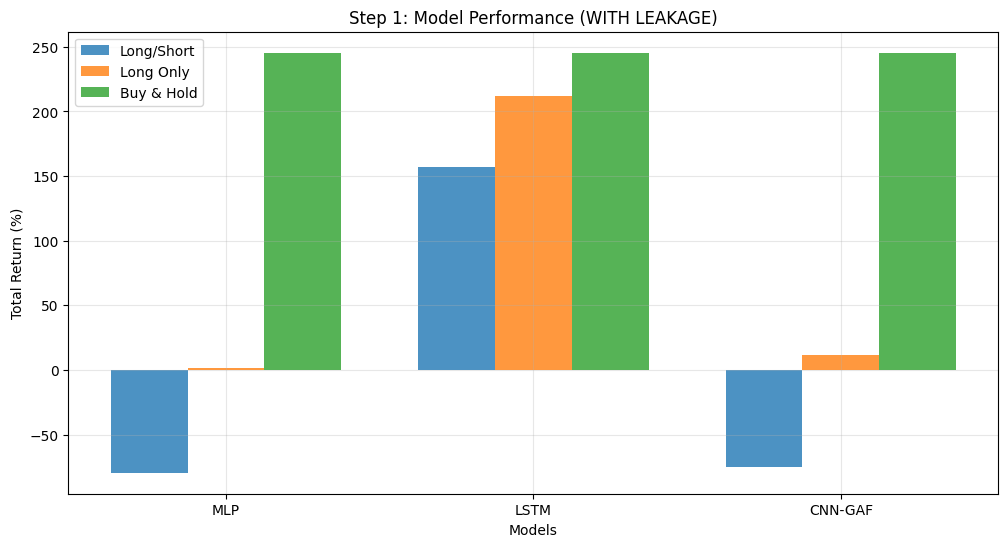

In [27]:
# Plot results
plt.figure(figsize=(12, 6))
models = list(results_step1.keys())
x = np.arange(len(models))

ls_returns = [results_step1[m]['returns'][0] for m in models]
l_returns = [results_step1[m]['returns'][1] for m in models]
bh_returns = [results_step1[m]['returns'][2] for m in models]

plt.bar(x - 0.25, ls_returns, 0.25, label='Long/Short', alpha=0.8)
plt.bar(x, l_returns, 0.25, label='Long Only', alpha=0.8)
plt.bar(x + 0.25, bh_returns, 0.25, label='Buy & Hold', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Total Return (%)')
plt.title('Step 1: Model Performance (WITH LEAKAGE)')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 2

In [28]:
def walk_forward_backtest(X, y, dates, original_df, n_train, n_test, model_type='MLP'):
    """
    Walk-forward validation with proper DataFrame handling
    """
    all_predictions = []
    i_iter = 0

    # Calculate maximum possible iterations
    max_start = len(y) - n_train - n_test
    if max_start <= 0:
        print(f"Error: Not enough data for {n_train} train + {n_test} test samples")
        return pd.DataFrame()

    for start in range(0, max_start + 1, n_test):
        end_train = start + n_train
        end_test = end_train + n_test

        if end_test > len(y):
            break

        # Get data slices
        X_train = X.iloc[start:end_train]
        y_train = y.iloc[start:end_train]
        X_test = X.iloc[end_train:end_test]
        y_test = y.iloc[end_train:end_test]
        test_dates = dates[end_train:end_test]

        print(f"Iter {i_iter}: Train {dates[start].strftime('%Y-%m-%d')} to {dates[end_train-1].strftime('%Y-%m-%d')}, "
              f"Test {dates[end_train].strftime('%Y-%m-%d')} to {dates[end_test-1].strftime('%Y-%m-%d')}")

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train model
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        try:
            if model_type == 'MLP':
                model = build_mlp_classifier(X_train_scaled.shape[1], hp_lr=1e-5)
                y_prob, y_pred = train_model(model, X_train_scaled, y_train,
                                           X_test_scaled, y_test, epochs=100)

            elif model_type == 'LSTM':
                X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
                X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
                model = build_lstm_classifier((X_train_lstm.shape[1], 1), hp_lr=1e-5)
                y_prob, y_pred = train_model(model, X_train_lstm, y_train,
                                           X_test_lstm, y_test, epochs=100)

            elif model_type == 'CNN-GAF':
                X_train_gaf = prepare_gaf_data(X_train_scaled)
                X_test_gaf = prepare_gaf_data(X_test_scaled)
                model = build_cnn_gaf_classifier(X_train_gaf.shape[1:], hp_lr=1e-5)
                y_prob, y_pred = train_model(model, X_train_gaf, y_train,
                                           X_test_gaf, y_test, epochs=50)

            # Store predictions
            for j in range(len(test_dates)):
                all_predictions.append({
                    'Date': test_dates[j],
                    'y_true': y_test.iloc[j],
                    'y_prob': y_prob[j],
                    'y_pred': y_pred[j]
                })

        except Exception as e:
            print(f"Error in iteration {i_iter}: {str(e)}")
            continue

        i_iter += 1

    if all_predictions:
        return pd.DataFrame(all_predictions)
    else:
        return pd.DataFrame()

Walk-Forward 500 train / 500 test

In [29]:
results_step2a = {}

In [30]:
for model_name in ['MLP', 'LSTM', 'CNN-GAF']:
    print(f"\nRunning {model_name} walk-forward (500/500)...")

    pred_df = walk_forward_backtest(X_leak, y_leak, dates, df, 500, 500, model_name)

    if len(pred_df) > 0:
        # Evaluate performance
        metrics = evaluate_model(pred_df['y_true'], pred_df['y_pred'],
                                pred_df['y_prob'], f"{model_name} WF(500/500)")

        # Backtest
        backtest_res, ret_ls, ret_l, ret_bh = backtest_strategy(pred_df, df,
                                                               f"{model_name} WF(500/500)")

        results_step2a[model_name] = {
            'metrics': metrics,
            'returns': [ret_ls, ret_l, ret_bh],
            'predictions': pred_df
        }
    else:
        print(f"No predictions generated for {model_name}")



Running MLP walk-forward (500/500)...
Iter 0: Train 2019-01-31 to 2020-06-13, Test 2020-06-14 to 2021-10-26
Iter 1: Train 2020-06-14 to 2021-10-26, Test 2021-10-27 to 2023-03-10

MLP WF(500/500) Performance:
  Accuracy: 0.6140
  Precision: 0.6500
  Recall: 0.6063
  F1: 0.6274
  ROC-AUC: 0.6208

MLP WF(500/500) Backtest Results:
  Long/Short Return: 1159.96%
  Long Only Return: 582.14%
  Buy & Hold Return: 115.06%
  Total Trades: 103

Running LSTM walk-forward (500/500)...
Iter 0: Train 2019-01-31 to 2020-06-13, Test 2020-06-14 to 2021-10-26
Iter 1: Train 2020-06-14 to 2021-10-26, Test 2021-10-27 to 2023-03-10

LSTM WF(500/500) Performance:
  Accuracy: 0.4660
  Precision: 0.5012
  Recall: 0.7556
  F1: 0.6027
  ROC-AUC: 0.4646

LSTM WF(500/500) Backtest Results:
  Long/Short Return: 2.98%
  Long Only Return: 70.69%
  Buy & Hold Return: 115.06%
  Total Trades: 49

Running CNN-GAF walk-forward (500/500)...
Iter 0: Train 2019-01-31 to 2020-06-13, Test 2020-06-14 to 2021-10-26
Iter 1: Train

Walk-Forward 500 train / 100 test

In [31]:
results_step2b = {}

In [32]:
for model_name in ['MLP', 'LSTM', 'CNN-GAF']:
    print(f"\nRunning {model_name} walk-forward (500/100)...")

    pred_df = walk_forward_backtest(X_leak, y_leak, dates, df, 500, 100, model_name)

    if len(pred_df) > 0:
        # Evaluate performance
        metrics = evaluate_model(pred_df['y_true'], pred_df['y_pred'],
                                pred_df['y_prob'], f"{model_name} WF(500/100)")

        # Backtest
        backtest_res, ret_ls, ret_l, ret_bh = backtest_strategy(pred_df, df,
                                                               f"{model_name} WF(500/100)")

        results_step2b[model_name] = {
            'metrics': metrics,
            'returns': [ret_ls, ret_l, ret_bh],
            'predictions': pred_df
        }
    else:
        print(f"No predictions generated for {model_name}")


Running MLP walk-forward (500/100)...
Iter 0: Train 2019-01-31 to 2020-06-13, Test 2020-06-14 to 2020-09-21
Iter 1: Train 2019-05-11 to 2020-09-21, Test 2020-09-22 to 2020-12-30
Iter 2: Train 2019-08-19 to 2020-12-30, Test 2020-12-31 to 2021-04-09
Iter 3: Train 2019-11-27 to 2021-04-09, Test 2021-04-10 to 2021-07-18
Iter 4: Train 2020-03-06 to 2021-07-18, Test 2021-07-19 to 2021-10-26
Iter 5: Train 2020-06-14 to 2021-10-26, Test 2021-10-27 to 2022-02-03
Iter 6: Train 2020-09-22 to 2022-02-03, Test 2022-02-04 to 2022-05-14
Iter 7: Train 2020-12-31 to 2022-05-14, Test 2022-05-15 to 2022-08-22
Iter 8: Train 2021-04-10 to 2022-08-22, Test 2022-08-23 to 2022-11-30
Iter 9: Train 2021-07-19 to 2022-11-30, Test 2022-12-01 to 2023-03-10
Iter 10: Train 2021-10-27 to 2023-03-10, Test 2023-03-11 to 2023-06-18
Iter 11: Train 2022-02-04 to 2023-06-18, Test 2023-06-19 to 2023-09-26
Iter 12: Train 2022-05-15 to 2023-09-26, Test 2023-09-27 to 2024-01-04
Iter 13: Train 2022-08-23 to 2024-01-04, Test 20

Compare Result

In [33]:
comparison_data = []
for model in ['MLP', 'LSTM', 'CNN-GAF']:
    row = [model]

    # Step 1
    if model in results_step1:
        row.extend([f"{results_step1[model]['metrics']['ROC-AUC']:.3f}",
                   f"{results_step1[model]['returns'][1]:.1f}%"])
    else:
        row.extend(["N/A", "N/A"])

    # Step 2a
    if model in results_step2a:
        row.extend([f"{results_step2a[model]['metrics']['ROC-AUC']:.3f}",
                   f"{results_step2a[model]['returns'][1]:.1f}%"])
    else:
        row.extend(["N/A", "N/A"])

    # Step 2b
    if model in results_step2b:
        row.extend([f"{results_step2b[model]['metrics']['ROC-AUC']:.3f}",
                   f"{results_step2b[model]['returns'][1]:.1f}%"])
    else:
        row.extend(["N/A", "N/A"])

    comparison_data.append(row)

In [34]:
# Print comparison table
headers = ['Model', 'Step1 AUC', 'Step1 Ret', 'Step2a AUC', 'Step2a Ret', 'Step2b AUC', 'Step2b Ret']
print(f"{'Model':<10} {'S1-AUC':<8} {'S1-Ret':<8} {'S2a-AUC':<9} {'S2a-Ret':<9} {'S2b-AUC':<9} {'S2b-Ret':<9}")
print("-" * 70)

for row in comparison_data:
    print(f"{row[0]:<10} {row[1]:<8} {row[2]:<8} {row[3]:<9} {row[4]:<9} {row[5]:<9} {row[6]:<9}")

Model      S1-AUC   S1-Ret   S2a-AUC   S2a-Ret   S2b-AUC   S2b-Ret  
----------------------------------------------------------------------
MLP        0.495    1.9%     0.621     582.1%    0.589     487.0%   
LSTM       0.474    211.6%   0.465     70.7%     0.447     253.5%   
CNN-GAF    0.431    11.3%    0.600     107.3%    0.484     -8.0%    


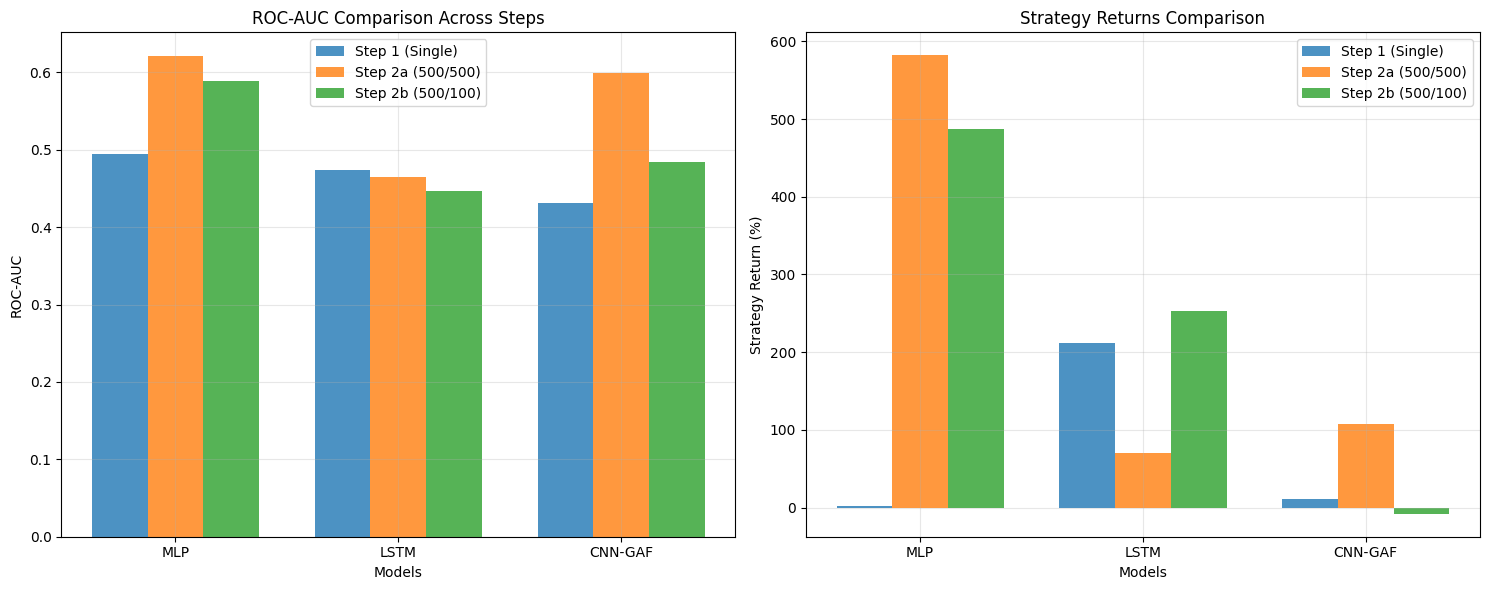

In [35]:
# Visualization
if results_step1 or results_step2a or results_step2b:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    models = ['MLP', 'LSTM', 'CNN-GAF']
    x = np.arange(len(models))

    # ROC-AUC comparison
    step1_auc = [results_step1[m]['metrics']['ROC-AUC'] if m in results_step1 else 0 for m in models]
    step2a_auc = [results_step2a[m]['metrics']['ROC-AUC'] if m in results_step2a else 0 for m in models]
    step2b_auc = [results_step2b[m]['metrics']['ROC-AUC'] if m in results_step2b else 0 for m in models]

    width = 0.25
    axes[0].bar(x - width, step1_auc, width, label='Step 1 (Single)', alpha=0.8)
    axes[0].bar(x, step2a_auc, width, label='Step 2a (500/500)', alpha=0.8)
    axes[0].bar(x + width, step2b_auc, width, label='Step 2b (500/100)', alpha=0.8)
    axes[0].set_xlabel('Models')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].set_title('ROC-AUC Comparison Across Steps')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Returns comparison
    step1_ret = [results_step1[m]['returns'][1] if m in results_step1 else 0 for m in models]
    step2a_ret = [results_step2a[m]['returns'][1] if m in results_step2a else 0 for m in models]
    step2b_ret = [results_step2b[m]['returns'][1] if m in results_step2b else 0 for m in models]

    axes[1].bar(x - width, step1_ret, width, label='Step 1 (Single)', alpha=0.8)
    axes[1].bar(x, step2a_ret, width, label='Step 2a (500/500)', alpha=0.8)
    axes[1].bar(x + width, step2b_ret, width, label='Step 2b (500/100)', alpha=0.8)
    axes[1].set_xlabel('Models')
    axes[1].set_ylabel('Strategy Return (%)')
    axes[1].set_title('Strategy Returns Comparison')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

EMBARGOED WALK-FORWARD (FIXING LEAKAGE)

In [36]:
df_clean = df[['ret']].copy()

# Same lagged features as before
for k in range(1, n_lag):
    df_clean[f'ret_lag{k}'] = df_clean['ret'].shift(k)

# FIXED TARGET: Use current period return (no future info)
df_clean['current_period_ret'] = df_clean['ret'].rolling(n_lag).apply(lambda x: np.prod(1 + x) - 1)
df_clean['target'] = np.where(df_clean['current_period_ret'] > 0, 1, 0)

# Clean up
df_clean = df_clean.dropna()

In [37]:
X_clean = df_clean.drop(columns=['target', 'current_period_ret'])
y_clean = df_clean['target']
dates_clean = df_clean.index

In [38]:
embargo_period = 30

In [ ]:
def embargoed_walk_forward(X, y, dates, original_df, n_train, n_test, embargo_days, model_type='MLP'):
    """
    Walk-forward with embargo period to prevent leakage
    """
    all_predictions = []
    i_iter = 0
    start = 0

    while True:
        train_end = start + n_train
        test_start = train_end + embargo_days  # Add embargo gap
        test_end = test_start + n_test

        if test_end > len(y):
            break

        # Get data slices
        X_train = X.iloc[start:train_end]
        y_train = y.iloc[start:train_end]
        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]
        test_dates = dates[test_start:test_end]

        print(f"Iter {i_iter}: Train {dates[start].strftime('%Y-%m-%d')} to {dates[train_end-1].strftime('%Y-%m-%d')}, "
              f"Gap {dates[train_end].strftime('%Y-%m-%d')} to {dates[test_start-1].strftime('%Y-%m-%d')}, "
              f"Test {dates[test_start].strftime('%Y-%m-%d')} to {dates[test_end-1].strftime('%Y-%m-%d')}")

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)#Fit to data, then transform it. Fits transformer to X and y with optional parameters fit_params and returns a transformed version of X.
        X_test_scaled = scaler.transform(X_test)#Perform standardization by centering and scaling.

        # Chronological validation split (no shuffle)
        val_size = int(0.15 * len(X_train_scaled))# set last 15% of training set as validation part
        if val_size > 0:
            X_fit = X_train_scaled[:-val_size]
            X_val = X_train_scaled[-val_size:]
            y_fit = y_train.iloc[:-val_size]# why using iloc?
            y_val = y_train.iloc[-val_size:]
        else:
            X_fit, X_val = X_train_scaled, None
            y_fit, y_val = y_train, None

        # Train model
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        try:
            if model_type == 'MLP':
                model = build_mlp_classifier(X_fit.shape[1], hp_lr=1e-5)

            elif model_type == 'LSTM':
                X_fit = X_fit.reshape(X_fit.shape[0], X_fit.shape[1], 1)
                X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
                if X_val is not None:
                    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
                model = build_lstm_classifier((X_fit.shape[1], 1), hp_lr=1e-5)

            elif model_type == 'CNN-GAF':
                X_fit = prepare_gaf_data(X_fit)
                X_test_scaled = prepare_gaf_data(X_test_scaled)
                if X_val is not None:
                    X_val = prepare_gaf_data(X_val)
                model = build_cnn_gaf_classifier(X_fit.shape[1:], hp_lr=1e-5)

            # Manual training with validation
            es = tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy" if X_val is not None else "accuracy",
                patience=15, restore_best_weights=True, verbose=0
            )

            # Class weights
            pos_count = sum(y_fit)
            neg_count = len(y_fit) - pos_count
            if pos_count > 0 and neg_count > 0:
                weight_pos = len(y_fit) / (2 * pos_count)
                weight_neg = len(y_fit) / (2 * neg_count)
                class_weight = {0: weight_neg, 1: weight_pos}
            else:
                class_weight = None

            if X_val is not None:
                model.fit(X_fit, y_fit.astype(int),
                         validation_data=(X_val, y_val.astype(int)),
                         epochs=100, batch_size=32, verbose=0,
                         callbacks=[es], shuffle=False, class_weight=class_weight)
            else:
                model.fit(X_fit, y_fit.astype(int),
                         epochs=100, batch_size=32, verbose=0,
                         shuffle=False, class_weight=class_weight)

            # Predict
            y_prob = model.predict(X_test_scaled, verbose=0).ravel()
            y_pred = (y_prob > 0.5).astype(int)

            # Store predictions
            for j in range(len(test_dates)):
                all_predictions.append({
                    'Date': test_dates[j],
                    'y_true': y_test.iloc[j],
                    'y_prob': y_prob[j],
                    'y_pred': y_pred[j]
                })

        except Exception as e:
            print(f"Error in iteration {i_iter}: {str(e)}")

        i_iter += 1
        start += n_test  # Move forward by test window size

    if all_predictions:
        return pd.DataFrame(all_predictions)
    else:
        return pd.DataFrame()

In [40]:
results_step3b = {}

In [41]:
for model_name in ['MLP', 'LSTM', 'CNN-GAF']:
    print(f"\nRunning {model_name} embargoed walk-forward (500/500)...")

    pred_df = embargoed_walk_forward(X_clean, y_clean, dates_clean, df,
                                   500, 500, embargo_period, model_name)

    if len(pred_df) > 0:
        metrics = evaluate_model(pred_df['y_true'], pred_df['y_pred'],
                                pred_df['y_prob'], f"{model_name} Embargo(500/500)")

        backtest_res, ret_ls, ret_l, ret_bh = backtest_strategy(pred_df, df,
                                                               f"{model_name} Embargo(500/500)")

        results_step3b[model_name] = {
            'metrics': metrics,
            'returns': [ret_ls, ret_l, ret_bh],
            'predictions': pred_df
        }


Running MLP embargoed walk-forward (500/500)...
Iter 0: Train 2019-01-31 to 2020-06-13, Gap 2020-06-14 to 2020-07-13, Test 2020-07-14 to 2021-11-25
Iter 1: Train 2020-06-14 to 2021-10-26, Gap 2021-10-27 to 2021-11-25, Test 2021-11-26 to 2023-04-09

MLP Embargo(500/500) Performance:
  Accuracy: 0.5930
  Precision: 0.6324
  Recall: 0.5746
  F1: 0.6022
  ROC-AUC: 0.6337

MLP Embargo(500/500) Backtest Results:
  Long/Short Return: 669.23%
  Long Only Return: 561.54%
  Buy & Hold Return: 206.53%
  Total Trades: 356

Running LSTM embargoed walk-forward (500/500)...
Iter 0: Train 2019-01-31 to 2020-06-13, Gap 2020-06-14 to 2020-07-13, Test 2020-07-14 to 2021-11-25
Iter 1: Train 2020-06-14 to 2021-10-26, Gap 2021-10-27 to 2021-11-25, Test 2021-11-26 to 2023-04-09

LSTM Embargo(500/500) Performance:
  Accuracy: 0.7340
  Precision: 0.8729
  Recall: 0.5896
  F1: 0.7038
  ROC-AUC: 0.8334

LSTM Embargo(500/500) Backtest Results:
  Long/Short Return: 287.44%
  Long Only Return: 413.26%
  Buy & Hold

In [42]:
results_step3c = {}

In [43]:
for model_name in ['MLP', 'LSTM', 'CNN-GAF']:
    print(f"\nRunning {model_name} embargoed walk-forward (500/100)...")

    pred_df = embargoed_walk_forward(X_clean, y_clean, dates_clean, df,
                                   500, 100, embargo_period, model_name)

    if len(pred_df) > 0:
        metrics = evaluate_model(pred_df['y_true'], pred_df['y_pred'],
                                pred_df['y_prob'], f"{model_name} Embargo(500/100)")

        backtest_res, ret_ls, ret_l, ret_bh = backtest_strategy(pred_df, df,
                                                               f"{model_name} Embargo(500/100)")

        results_step3c[model_name] = {
            'metrics': metrics,
            'returns': [ret_ls, ret_l, ret_bh],
            'predictions': pred_df
        }


Running MLP embargoed walk-forward (500/100)...
Iter 0: Train 2019-01-31 to 2020-06-13, Gap 2020-06-14 to 2020-07-13, Test 2020-07-14 to 2020-10-21
Iter 1: Train 2019-05-11 to 2020-09-21, Gap 2020-09-22 to 2020-10-21, Test 2020-10-22 to 2021-01-29
Iter 2: Train 2019-08-19 to 2020-12-30, Gap 2020-12-31 to 2021-01-29, Test 2021-01-30 to 2021-05-09
Iter 3: Train 2019-11-27 to 2021-04-09, Gap 2021-04-10 to 2021-05-09, Test 2021-05-10 to 2021-08-17
Iter 4: Train 2020-03-06 to 2021-07-18, Gap 2021-07-19 to 2021-08-17, Test 2021-08-18 to 2021-11-25
Iter 5: Train 2020-06-14 to 2021-10-26, Gap 2021-10-27 to 2021-11-25, Test 2021-11-26 to 2022-03-05
Iter 6: Train 2020-09-22 to 2022-02-03, Gap 2022-02-04 to 2022-03-05, Test 2022-03-06 to 2022-06-13
Iter 7: Train 2020-12-31 to 2022-05-14, Gap 2022-05-15 to 2022-06-13, Test 2022-06-14 to 2022-09-21
Iter 8: Train 2021-04-10 to 2022-08-22, Gap 2022-08-23 to 2022-09-21, Test 2022-09-22 to 2022-12-30
Iter 9: Train 2021-07-19 to 2022-11-30, Gap 2022-12

Final Analysis - Has Overfitting Disappeared?

In [44]:
if any([results_step1, results_step2a, results_step2b, results_step3b, results_step3c]):
    print(f"{'Model':<8} {'Step1':<8} {'Step2a':<8} {'Step2b':<8} {'Step3b':<8} {'Step3c':<8}")
    print(f"{'(AUC)':<8} {'Single':<8} {'WF500/500':<8} {'WF500/100':<8} {'Emb500/500':<8} {'Emb500/100':<8}")
    print("-" * 60)

    for model in ['MLP', 'LSTM', 'CNN-GAF']:
        row = f"{model:<8}"

        # Step 1
        row += f"{results_step1[model]['metrics']['ROC-AUC']:.3f}    " if model in results_step1 else "N/A      "

        # Step 2a
        row += f"{results_step2a[model]['metrics']['ROC-AUC']:.3f}     " if model in results_step2a else "N/A      "

        # Step 2b
        row += f"{results_step2b[model]['metrics']['ROC-AUC']:.3f}     " if model in results_step2b else "N/A      "

        # Step 3b
        row += f"{results_step3b[model]['metrics']['ROC-AUC']:.3f}      " if model in results_step3b else "N/A       "

        # Step 3c
        row += f"{results_step3c[model]['metrics']['ROC-AUC']:.3f}" if model in results_step3c else "N/A"

        print(row)

Model    Step1    Step2a   Step2b   Step3b   Step3c  
(AUC)    Single   WF500/500 WF500/100 Emb500/500 Emb500/100
------------------------------------------------------------
MLP     0.495    0.621     0.589     0.634      0.648
LSTM    0.474    0.465     0.447     0.833      0.741
CNN-GAF 0.431    0.600     0.484     0.638      0.489
